# DEEP DIVE

In [1]:
%load_ext autoreload
%autoreload 2

## Data requirements survey

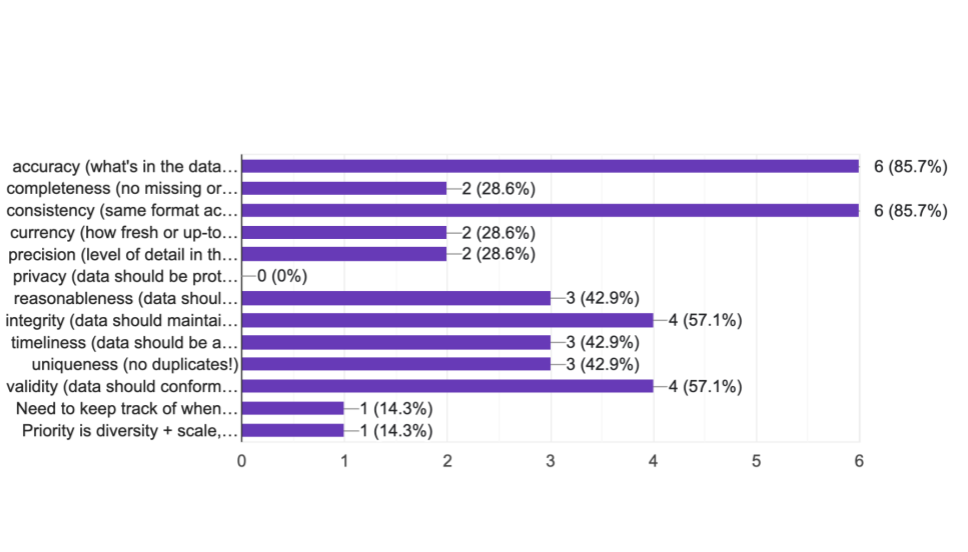

In [28]:
from IPython.display import Image, display

display(Image("/Users/gagan/esp_projects/EspDataDeepdive/assets/data_req1.png", width=1000, height=500))

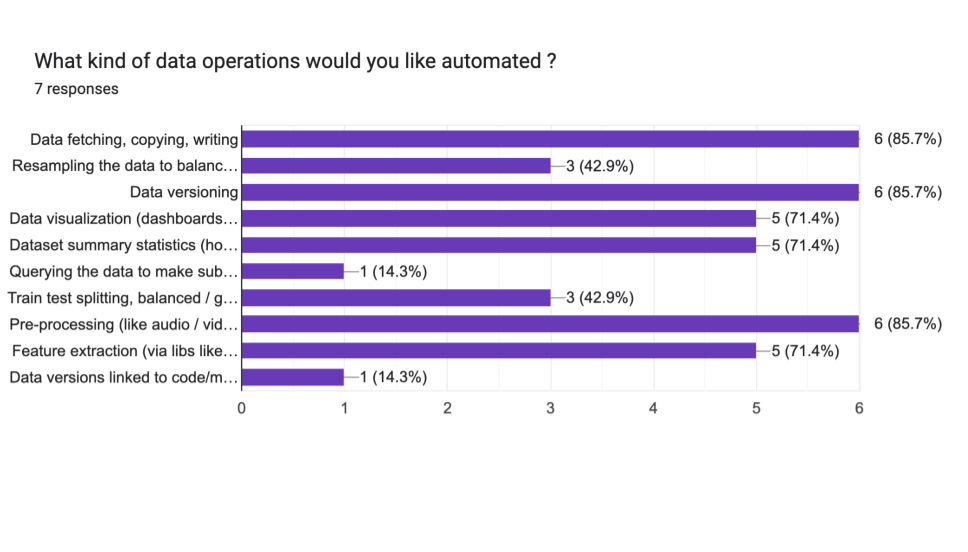

In [37]:
display(Image("/Users/gagan/esp_projects/EspDataDeepdive/assets/data_req2.png", width=1000, height=500))

## esp-data

```
├── README.md
├── docs
├── esp_data
│   ├── __init__.py
│   ├── config
│   │   ├── __init__.py
│   │   ├── db_config.py
│   │   └── project_config.py
│   ├── dataset
│   │   ├── __init__.py
│   │   ├── base.py
│   │   ├── datasets.py
│   │   ├── hf.py
│   │   ├── shard_creator.py
│   │   ├── transforms.py
│   │   ├── utils.py
│   │   └── webds.py
│   ├── db
│   │   ├── __init__.py
│   │   ├── bq.py
│   │   ├── caches.py
│   │   └── utils.py
│   ├── file_io
│   │   ├── __init__.py
│   │   ├── buckets.py
│   │   ├── files.py
│   │   ├── functional.py
│   │   ├── parsers.py
│   │   └── utils.py
│   ├── paths.py
│   └── utils.py
├── notebooks
├── pyproject.toml
├── uv.lock
├── requirements.txt
├── scripts
├── tests
```

## Paths
### How to manage local and cloud paths ? 

In [2]:
from esp_data.paths import AnyPath

p = AnyPath("../tests/fileio_test_folder/file1.txt")

print(p)
print(type(p))

../tests/fileio_test_folder/file1.txt
<class 'pathlib.PosixPath'>


In [4]:
# get extension
print(p.suffix)
# split path
print(p.parts)

.txt
('..', 'tests', 'fileio_test_folder', 'file1.txt')


In [10]:
p = AnyPath("gs://esp-ci-cd-tests/esp-data-tests/")
print(type(p))
print(p.exists())

<class 'esp_data.paths.GSPath'>
True


#### We also have CloudFlare R2 buckets!

In [11]:
p = AnyPath("r2://esp-ci-cd-tests/esp-data-tests/")
print(type(p))
print(p.exists())
print(p.is_dir())
print(list(p.rglob("**/*local.txt")))

<class 'cloudpathlib.s3.s3path.S3Path'>
True
True
[S3Path('s3://esp-ci-cd-tests/esp-data-tests/temprandomfolder/random_local.txt'), S3Path('s3://esp-ci-cd-tests/esp-data-tests/temprandomfolder/random_local.txt')]


#### delete a file
```p.unlink()```
#### rename a file (moves it to a new location)
```p.rename(target=)```
#### open a file for read or write, mode = "r" or "w" or "rb"
```p.open(mode="r")```
#### download 
```p.download_to("local_file.txt")```
#### upload a file to a cloud location
```p.upload_from("/path/to/myfile.txt")```

See more here:
https://cloudpathlib.drivendata.org/stable/api-reference/cloudpath/

### Joining paths

In [7]:
p = AnyPath("gs://esp-ci-cd-tests/esp-data-tests/") / "some_subfolder/nri-battlesounds.mp3"
print(p)

gs://esp-ci-cd-tests/esp-data-tests/some_subfolder/nri-battlesounds.mp3


## Functional API for File I/O

In [14]:
import esp_data.file_io.functional as F

#### F has the following functions
* copy
* create_file
* delete_dir
* makedirs
* delete_file
* download
* exists
* gcloud_rsync
* list_files
* yield_files
* open_file
* read_bytes
* read_text
* upload
* write_bytes
* write_rows_to_csv
* write_text

In [8]:
F.yield_files?

Signature:
F.yield_files(
    dir_path: str | os.PathLike | esp_data.paths.AnyPath,
    pattern: str = '*',
    use_fs: bool = False,
)
Docstring:
Yield files in the given directory.

Args:
    dir_path (str | os.PathLike | AnyPath): The path to the directory.
    pattern (str, optional): A pattern to match the files. Defaults to "*".
    use_fs (bool, optional): If True, use the FileSystem approach. Defaults to False, which is using cloudpathlib.

Yields:
    str: A file path if successful.
File:      ~/esp_projects/esp-data/esp_data/file_io/functional.py
Type:      function

#### Check for file exists

In [9]:
p = AnyPath("gs://esp-ci-cd-tests/esp-data-tests/") / "some_subfolder/nri-battlesounds.mp3"
print(F.exists(p))

True


#### Download a file 

In [10]:
F.download(p, destination="/Users/gagan/Desktop/")
F.exists("/Users/gagan/Desktop/nri-battlesounds.mp3")

True

#### Yield file names in a bucket

In [20]:
%%time
for file in F.yield_files("gs://esp-ci-cd-tests/esp-data-tests/", pattern="*"):
    print(file)

gs://esp-ci-cd-tests/esp-data-tests/random2.txt
gs://esp-ci-cd-tests/esp-data-tests/temp
gs://esp-ci-cd-tests/esp-data-tests/test_csv.csv
gs://esp-ci-cd-tests/esp-data-tests/delete_files_tests/.temp
gs://esp-ci-cd-tests/esp-data-tests/dir_tests_list/.temp
gs://esp-ci-cd-tests/esp-data-tests/find_files_tests/.temp
gs://esp-ci-cd-tests/esp-data-tests/find_files_tests/file_find_cloud.txt
gs://esp-ci-cd-tests/esp-data-tests/non_empty/temp_file.txt
gs://esp-ci-cd-tests/esp-data-tests/non_empty/test.csv
gs://esp-ci-cd-tests/esp-data-tests/some_subfolder/nri-battlesounds.mp3
gs://esp-ci-cd-tests/esp-data-tests/some_subfolder/random.txt
gs://esp-ci-cd-tests/esp-data-tests/some_subfolder/temp_file.txt
gs://esp-ci-cd-tests/esp-data-tests/subfolder/file1.txt
gs://esp-ci-cd-tests/esp-data-tests/subfolder/file2.txt
gs://esp-ci-cd-tests/esp-data-tests/subfolder/random1.txt
gs://esp-ci-cd-tests/esp-data-tests/subfolder/random2.txt
gs://esp-ci-cd-tests/esp-data-tests/subfolder/subfolder
gs://esp-ci-cd

#### Open a remote file for read

In [12]:
# find byte -> numpy parsers here!
from esp_data.file_io.parsers import read_audio_bytes

In [15]:
p = AnyPath("gs://esp-ci-cd-tests/esp-data-tests/") / "some_subfolder/nri-battlesounds.mp3"

with F.open_file(str(p), mode="rb") as f:
    audio_data, sr = read_audio_bytes(f.read(), extension="mp3")
    print(type(audio_data))
    print(f"Sample rate = {sr}")

<class 'numpy.ndarray'>
Sample rate = 44100


####  Open a remote file for write

In [11]:
import json

cfg = {"some-int": 2, "foo": "bar"}
p = AnyPath("gs://esp-ci-cd-tests/esp-data-tests/") / "some_subfolder/test_cfg.json"

with F.open_file(str(p), mode="w") as f:
    json.dump(cfg, f)

with F.open_file(str(p), mode="r") as f:
    cfg2 = json.load(f)

cfg == cfg2

True

#### GCP rsync

In [8]:
F.gcloud_rsync(
    source="gs://esp-ci-cd-tests/esp-data-tests/some_subfolder",
    destination="gs://esp-ci-cd-tests/esp-data-tests/newfolder",
    avoid_copy_if_same=True,
    gzip_in_flight="txt",
)

2025-03-02 18:05:49,655 - fileio_functional - INFO - Rsync completed successfully


In [18]:
%%time
F.list_files("gs://esp-ci-cd-tests/esp-data-tests/newfolder", pattern="*")

CPU times: user 15.7 ms, sys: 6.34 ms, total: 22.1 ms
Wall time: 478 ms


['gs://esp-ci-cd-tests/esp-data-tests/newfolder/nri-battlesounds.mp3',
 'gs://esp-ci-cd-tests/esp-data-tests/newfolder/random.txt',
 'gs://esp-ci-cd-tests/esp-data-tests/newfolder/temp_file.txt',
 'gs://esp-ci-cd-tests/esp-data-tests/newfolder/test_cfg.json']

In [ ]:
F.delete_dir("gs://esp-ci-cd-tests/esp-data-tests/newfolder")

In [7]:
F.exists("gs://esp-ci-cd-tests/esp-data-tests/newfolder")

False

## Configs and data validation

#### We use pydantic for data models 

Check here for a nice tutorial from Milad! https://www.notion.so/earthspecies/Pydantic-basics-in-5-mins-17becbb680d080aebfdace6b3f937185

In [16]:
from typing import Optional

from pydantic import Field, field_validator

from esp_data.config import DataSample, DatasetConfig

In [17]:
class ExampleSample(DataSample):
    """Defines the structure of a Beans0 sample.

    Fields inherited from DataSample:
        - source_dataset: str
        - license: str | None
        - metadata: dict | None
        - created_at: datetime (generated)
        - id: str (generated)
        - derived_from: str | None
        - version: str | None
    """

    # required
    file_name: str = Field(description="Audio filename, could be a url")

    @field_validator("file_name", mode="after")
    @classmethod
    def validate_file_name(cls, v: str) -> str:
        if AnyPath(v).suffix not in [".flac", ".mp3", ".wav"]:
            raise ValueError("Audio type not supported!")


beans0_sample = ExampleSample(file_name="something.ogg", source_dataset="foo", license="bar", metadata={})

ValidationError: 1 validation error for ExampleSample
file_name
  Value error, Audio type not supported! [type=value_error, input_value='something.ogg', input_type=str]
    For further information visit https://errors.pydantic.dev/2.10/v/value_error

#### Dataset configs are also useful!

In [18]:
class Beans0DatasetConfig(DatasetConfig):
    """Defines the structure of a Beans0 dataset config.

    Fields inherited from DatasetConfig:
        - name: str
        - description: str
        - sources: list[str] | str
        - license: str
        - creator: str
        - version: str
        - created_at: str (generated datetime UTC)
        - changelog: str (optional)
    """

    metadata: Optional[dict] = Field(default_factory=lambda: {}, description="The metadata for the whole dataset")

In [19]:
cfg = {
    "name": "TEST",
    "creator": "Foo",
    "version": "0.0.0",
    "description": "Bar",
    "sources": "test",
    "license": "CC-BY-4.0",
}

beans0_cfg = Beans0DatasetConfig(**cfg)

In [20]:
beans0_cfg.update_changelog("Did something to the data")

In [21]:
beans0_cfg.generate_readme("README.md")

In [40]:
F.list_files("gs://esp-ml-datasets/beans0/processed/v0.1.0/", pattern="*md")

['gs://esp-ml-datasets/beans0/processed/v0.1.0/README.md']

In [22]:
print(F.read_text("gs://esp-ml-datasets/beans0/processed/v0.1.0/README.md"))

# Beans0
        ## Version

0.1.0


        ## Created At

2025-03-02 12:35:11.528403+00:00


        ## Creator

M.Hagiwara, masato at earthspecies dot org;
D. Robinson, david at earthspecies dot org;
M. Miron, marius at earthspecies dot org;
S. Keen, sara at earthspecies dot org;
G. Narula, gagan at earthspecies dot org;
M. Alizadeh, milad at earthspecies dot org;
O. Pietquin, olivier at earthspecies dot org


        ## License

The component datasets either have dataset level licenses or per file licenses.

    esc50: CC-BY-NC,
    rfcx: academic, research & non-commercial use,
    cbi: CC-BY-NC-SA,
    humbugdb": CC-BY,
    enabirds: CC0,
    hiceas: data are free to use without restriction,
    watkins: free for personal/academic uses,
    gibbons: CC-BY-NC-SA,
    lifestage: per file licenses, please see individual files,
    call-type: per file licenses, please see individual files,
    unseen-species-cmn: per file licenses, please see individual files,
    unseen-species-sci:

## Utilities

In [23]:
from esp_data.utils import make_id, make_simple_logger, run_as_async, utc_now_str

In [24]:
utc_now_str()

'2025-03-04T14:22:36.430329+00:00'

In [25]:
make_id()

'602cc7d7-1dac-4d82-8a62-3304950e3e65'

#### Make a simple console logger


In [24]:
logger = make_simple_logger("my_logger", add_file_handler=False)
logger.info("Yipee!")

2025-03-04 17:39:52,903 - my_logger - INFO - Yipee!


#### Run a background task

In [21]:
import asyncio


def copy_something_to_cloud_and_delete(source: str):
    F.upload(source=source, destination="gs://esp-ci-cd-tests/esp-data-tests/teststests/fileio_test_folder/file1.txt")
    F.delete_file("gs://esp-ci-cd-tests/esp-data-tests/teststests/fileio_test_folder/file1.txt")
    print("File exists ? ", F.exists("gs://esp-ci-cd-tests/esp-data-tests/teststests/fileio_test_folder/file1.txt"))


# creates non-blocking task
asyncio.create_task(run_as_async(copy_something_to_cloud_and_delete, source="../tests/fileio_test_folder/file1.txt"))

print("Print me first")

Print me first
File exists ?  False


## Datasets

#### Creating sharded datasets

One of the issues we have is that most of our datasets are collections of a very large number of files.

This has some disadvantages:
- Too much time spent copying files
- Corrupt files may be mixed in with normal files
- Can't stream the dataset easily
- Hard to index into
- ....

Sharding is the idea that we should aggregate data into fewer, but larger chunks in formats that allow for 
things like *memory mapping* or *streaming* and faster, copying around.

In [27]:
import numpy as np
import pandas as pd

from esp_data.utils import make_id


def make_dummy_dataset(N: int):
    # dummy dataset
    cols = ["col1_str", "col2_int", "col3_jsonstr", "col4_float", "id"]
    data = {}
    data[cols[0]] = [f"str_{i}" for i in range(N)]
    data[cols[1]] = [i for i in range(N)]
    data[cols[2]] = [f'{{"key_{i}": "value_{i}"}}' for i in range(N)]
    data[cols[3]] = [i * 0.1 for i in range(N)]
    data[cols[4]] = make_id()

    return data


df = pd.DataFrame(make_dummy_dataset(N=1000))

### Creating sharded datasets

In [31]:
from esp_data.dataset.shard_creator import write_shard

In [32]:
# Create batches of a dataframe
num_samples_per_shard = 100
num_samples = len(df)
num_shards = int(np.ceil(num_samples / num_samples_per_shard))
batched_df = np.array_split(df, num_shards)
print(f"Number of shards that will be created: {num_shards}")

Number of shards that will be created: 10


/Users/gagan/esp_projects/esp-data/.venv/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [33]:
output_path = "gs://esp-ci-cd-tests/esp-data-tests/benchmark_dataset/arrow_dataset/tempfolder"

In [34]:
processed_samples = []
failed_samples = []
for i, batch in enumerate(batched_df):
    res = write_shard(df, shard_id=i, output_path=output_path, output_format="arrow", sample_prep_function=None)

    processed_samples.append(res["processed_samples"])
    failed_samples.append(res["failed_ids"])

Shard 00000:   0%|                                               | 0/1000 [00:00<?, ?it/s]

Shard 00001:   0%|                                               | 0/1000 [00:00<?, ?it/s]

Shard 00002:   0%|                                               | 0/1000 [00:00<?, ?it/s]

Shard 00003:   0%|                                               | 0/1000 [00:00<?, ?it/s]

Shard 00004:   0%|                                               | 0/1000 [00:00<?, ?it/s]

Shard 00005:   0%|                                               | 0/1000 [00:00<?, ?it/s]

Shard 00006:   0%|                                               | 0/1000 [00:00<?, ?it/s]

Shard 00007:   0%|                                               | 0/1000 [00:00<?, ?it/s]

Shard 00008:   0%|                                               | 0/1000 [00:00<?, ?it/s]

Shard 00009:   0%|                                               | 0/1000 [00:00<?, ?it/s]

In [35]:
F.list_files("gs://esp-ci-cd-tests/esp-data-tests/benchmark_dataset/arrow_dataset/tempfolder")

['gs://esp-ci-cd-tests/esp-data-tests/benchmark_dataset/arrow_dataset/tempfolder/shard_000000.arrow',
 'gs://esp-ci-cd-tests/esp-data-tests/benchmark_dataset/arrow_dataset/tempfolder/shard_000001.arrow',
 'gs://esp-ci-cd-tests/esp-data-tests/benchmark_dataset/arrow_dataset/tempfolder/shard_000002.arrow',
 'gs://esp-ci-cd-tests/esp-data-tests/benchmark_dataset/arrow_dataset/tempfolder/shard_000003.arrow',
 'gs://esp-ci-cd-tests/esp-data-tests/benchmark_dataset/arrow_dataset/tempfolder/shard_000004.arrow',
 'gs://esp-ci-cd-tests/esp-data-tests/benchmark_dataset/arrow_dataset/tempfolder/shard_000005.arrow',
 'gs://esp-ci-cd-tests/esp-data-tests/benchmark_dataset/arrow_dataset/tempfolder/shard_000006.arrow',
 'gs://esp-ci-cd-tests/esp-data-tests/benchmark_dataset/arrow_dataset/tempfolder/shard_000007.arrow',
 'gs://esp-ci-cd-tests/esp-data-tests/benchmark_dataset/arrow_dataset/tempfolder/shard_000008.arrow',
 'gs://esp-ci-cd-tests/esp-data-tests/benchmark_dataset/arrow_dataset/tempfolder/s

### Loading datasets

In [36]:
from esp_data.dataset.datasets import load_dataset as lds

Load a dataset with copy to local huggingface cache (".cache/huggingface/datasets")

In [38]:
ds = lds(
    dataset_type="bucket_hf",
    path="gs://esp-ci-cd-tests/esp-data-tests/benchmark_dataset/arrow_dataset/tempfolder",
    streaming=False,
    file_pattern="shard*arrow",
)

2025-03-04 15:29:13,603 - hf_dataset - WARNING - Config file not found at gs://esp-ci-cd-tests/esp-data-tests/benchmark_dataset/arrow_dataset/tempfolder/dataset_config.json, creating an empty new one


Generating train split: 0 examples [00:00, ? examples/s]

In [41]:
ds

HFDataset: unknown, version: 0.0.0, num samples: 10000, columns: ['col1_str', 'col2_int', 'col3_jsonstr', 'col4_float', 'id']

In [42]:
len(ds)

10000

In [43]:
ds[0]

{'col1_str': 'str_0',
 'col2_int': 0,
 'col3_jsonstr': '{"key_0": "value_0"}',
 'col4_float': 0.0,
 'id': 'c829c9ae-a57d-400b-9224-c22b0c170df7'}

In [33]:
ds.save_to_path("./tempfolder")

Saving the dataset (0/1 shards):   0%|          | 0/10000 [00:00<?, ? examples/s]

In [34]:
dslocal = lds(dataset_type="local_hf", path="./tempfolder", streaming=False, split="train")

In [35]:
dslocal

HFDataset: unknown, version: 0.0.0, num samples: 10000, columns: ['col1_str', 'col2_int', 'col3_jsonstr', 'col4_float', 'id']

Let's load a dataset from huggingface hub

In [44]:
ds1 = lds(dataset_type="hf_hub", path="stanfordnlp/imdb", trust_remote_code=True, split="train")
ds1

HFDataset: imdb, version: 0.0.0, num samples: 25000, columns: ['text', 'label']

In [45]:
ds1.config

DatasetConfig(name='imdb', creator='see description', version='0.0.0', description="DatasetInfo(description='', citation='', homepage='', license='', features={'text': Value(dtype='string', id=None), 'label': ClassLabel(names=['neg', 'pos'], id=None)}, post_processed=None, supervised_keys=None, builder_name='parquet', dataset_name='imdb', config_name='plain_text', version=0.0.0, splits={'train': SplitInfo(name='train', num_bytes=33435948, num_examples=25000, shard_lengths=None, dataset_name='imdb'), 'test': SplitInfo(name='test', num_bytes=32653810, num_examples=25000, shard_lengths=None, dataset_name='imdb'), 'unsupervised': SplitInfo(name='unsupervised', num_bytes=67113044, num_examples=50000, shard_lengths=None, dataset_name='imdb')}, download_checksums={'hf://datasets/stanfordnlp/imdb@e6281661ce1c48d982bc483cf8a173c1bbeb5d31/plain_text/train-00000-of-00001.parquet': {'num_bytes': 20979968, 'checksum': None}, 'hf://datasets/stanfordnlp/imdb@e6281661ce1c48d982bc483cf8a173c1bbeb5d31/p

Load a csv (or tsv, json, parquet..) dataset from a bucket with pandas

In [46]:
ds2 = lds(dataset_type="pandas", path="gs://esp-ci-cd-tests/esp-data-tests/benchmark_dataset/csv_dataset/test.csv")

In [47]:
ds2.shape

(1000, 5)

In [48]:
ds2.head(2)

,col1_str,col2_int,col3_jsonstr,col4_float,id
0,str_0,0,"{""key_0"": ""value_0""}",0.0,69ecb927-3e58-4545-b1d0-c6951fa957d3
1,str_1,1,"{""key_1"": ""value_1""}",0.1,69ecb927-3e58-4545-b1d0-c6951fa957d3


#### Streaming data

In [49]:
from esp_data.dataset.datasets import load_dataset as lds

In [50]:
import json

from esp_data.file_io.parsers import read_audio_bytes


def data_processor(data: dict):
    audio, _ = read_audio_bytes(data["audio.wav"], "wav")
    metadata = json.loads(data["metadata.json"])
    return {"audio": audio, **metadata}

In [51]:
ds = lds(
    "webdataset",
    path="gs://esp-ml-datasets/beans0/processed/v0.1.1/",
    file_pattern="shard*tar",
    load_metadata=False,  # This will try and load a metadata.xx (csv, parquet or json) file, which contains an index
    data_processor=data_processor,
    shuffle_size=1000,
)

In [53]:
for sample in ds:
    break

Exception ignored in: <_io.TextIOWrapper name='<stdout>' mode='w' encoding='utf-8'>
BrokenPipeError: [Errno 32] Broken pipe
Exception ignored in: <function Pipe.__del__ at 0x16957e050>
Traceback (most recent call last):
  File "/Users/gagan/esp_projects/esp-data/.venv/lib/python3.10/site-packages/webdataset/gopen.py", line 147, in __del__
    self.close()
  File "/Users/gagan/esp_projects/esp-data/.venv/lib/python3.10/site-packages/webdataset/gopen.py", line 135, in close
    self.wait_for_child()
  File "/Users/gagan/esp_projects/esp-data/.venv/lib/python3.10/site-packages/webdataset/gopen.py", line 85, in wait_for_child
    raise IOError(f"{self.args}: exit {self.status} (read) {info}")
OSError: (("gsutil cat 'gs://esp-ml-datasets/beans0/processed/v0.1.1/shard_000054.tar'",), {'shell': True, 'bufsize': 8192}): exit 120 (read) {}


In [54]:
sample.keys()

dict_keys(['audio', 'source_dataset', 'metadata', 'id', 'created_at', 'license', 'file_name', 'instruction', 'instruction_text', 'output', 'task', 'dataset_name', '__key__'])

In [55]:
sample["audio"].shape

(53570,)

In [56]:
sample["license"]

'CC BY-NC'

In [57]:
sample["instruction_text"]

'What is the common name for the focal species in the audio?'

Let's compute mel spectrograms on the audio in a **streaming** mode :-)

In [58]:
import torch
import torchaudio.transforms as T


def mel_spec(sample: dict, n_fft: int = 512, hop_size: int = 256, normalized: bool = True):
    metadata = json.loads(sample["metadata"])
    sr = metadata.get("sample_rate", 16000)
    audio = torch.Tensor(sample["audio"])
    transform = T.MelSpectrogram(sample_rate=sr, n_fft=n_fft, n_mels=32, normalized=normalized)
    mel_specgram = transform(audio)
    sample["mel_spec"] = mel_specgram
    return sample

In [ ]:
from tqdm.notebook import tqdm

from esp_data.dataset.webds import apply_fn

In [ ]:
batch = []

for sample in tqdm(apply_fn(ds, mel_spec, fn_kwargs={"n_fft": 256, "hop_size": 128})):
    batch.append(sample)
    if len(batch) > 10:
        break

In [25]:
len(batch)

11

In [26]:
batch[-1].keys()

dict_keys(['audio', 'source_dataset', 'metadata', 'id', 'created_at', 'license', 'file_name', 'instruction', 'instruction_text', 'output', 'task', 'dataset_name', '__key__', 'mel_spec'])

### Batched streaming with webdataset

Let's compute mel spectrograms in batches directly without using the apply_fn

In [66]:
import torch.nn.functional as nnf


def torch_mel_spec(data: dict) -> torch.Tensor:
    """Create mel spectrograms on the fly"""
    data = data_processor(data)
    audio = torch.from_numpy(data["audio"]).to(torch.float32)

    sr = data.get("sample_rate", 16000)
    if sr != 16000:
        resampler = T.Resample(sr, new_freq=16000)
        audio = resampler(audio)

    # clip to max len 10 sec
    maxlen = 10 * 16000
    audio = audio[:maxlen]
    # or pad to 10 sec
    if len(audio) < maxlen:
        audio = nnf.pad(audio, (1, maxlen - len(audio) - 1), "constant", 0)

    transform = T.MelSpectrogram(sample_rate=16000, n_fft=256, n_mels=32)
    mel_specgram = transform(audio)
    return mel_specgram

In [67]:
ds = lds(
    "webdataset",
    path="gs://esp-ml-datasets/beans0/processed/v0.1.1/",
    file_pattern="shard*tar",
    load_metadata=False,
    data_processor=torch_mel_spec,
    shuffle_size=1000,
    batch_size=100,
    batch_collate_fn=torch.stack,
)

In [68]:
%%time
for batch in ds:
    break

Exception ignored in: <_io.TextIOWrapper name='<stdout>' mode='w' encoding='utf-8'>
BrokenPipeError: [Errno 32] Broken pipe
Exception ignored in: <function Pipe.__del__ at 0x16957e050>
Traceback (most recent call last):
  File "/Users/gagan/esp_projects/esp-data/.venv/lib/python3.10/site-packages/webdataset/gopen.py", line 147, in __del__
    self.close()
  File "/Users/gagan/esp_projects/esp-data/.venv/lib/python3.10/site-packages/webdataset/gopen.py", line 135, in close
    self.wait_for_child()
  File "/Users/gagan/esp_projects/esp-data/.venv/lib/python3.10/site-packages/webdataset/gopen.py", line 85, in wait_for_child
    raise IOError(f"{self.args}: exit {self.status} (read) {info}")
OSError: (("gsutil cat 'gs://esp-ml-datasets/beans0/processed/v0.1.1/shard_000000.tar'",), {'shell': True, 'bufsize': 8192}): exit 120 (read) {}


CPU times: user 39.5 s, sys: 13.3 s, total: 52.8 s
Wall time: 13 s


In [69]:
batch.shape

torch.Size([100, 32, 1251])